# Denoising Diffusion Probabilistic Model (DDPM) for MNIST
## PyTorch Version — with GPU support

This notebook is the **PyTorch equivalent** of the pure-NumPy DDPM notebook.
Every equation and algorithm is identical; what changes is the implementation:
PyTorch handles automatic differentiation, the DataLoader batches the data,
and `device` moves tensors to GPU if one is available.

**Improvements over the NumPy version:**

| Feature | NumPy | PyTorch |
|:--------|:------|:--------|
| Differentiation | Manual backprop | `loss.backward()` |
| Activation | ReLU | SiLU (smoother, better for diffusion) |
| Normalisation | None | `GroupNorm` after each dense block |
| Time MLP | Single projection | Two-layer MLP |
| GPU | ✗ | ✓ (automatic) |
| Speed | Slow | Fast |

**Contents**

| § | Topic |
|:--|:------|
| 1 | Theory (same as NumPy version — recap) |
| 2 | Imports and helpers |
| 3 | Noise schedule and `q_sample` |
| 4 | Sinusoidal time embedding |
| 5 | `DiffusionMLP` as `nn.Module` |
| 6 | MNIST loading with `DataLoader` |
| 7 | Forward diffusion visualisation |
| 8 | Training loop |
| 9 | DDPM sampling |
| 10 | DDIM accelerated sampling |
| 11 | Analysis |

## 1. Theory — Recap

*(Full derivation in the NumPy notebook.  Brief recap here.)*

**Forward process** — one-shot marginal:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon\sim\mathcal{N}(0,\mathbf{I}),
\qquad \bar\alpha_t = \prod_{s=1}^t(1-\beta_s)$$

**Training objective** — noise-prediction MSE:

$$\mathcal{L} = \mathbb{E}_{t,x_0,\varepsilon}\!
\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right]$$

**DDPM reverse step** (stochastic):

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}
\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right)
+\sqrt{\tilde\beta_t}\,z, \quad z\sim\mathcal{N}(0,\mathbf{I})$$

**DDIM reverse step** (deterministic, $\eta=0$, 50 steps):

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat{x}_0
+\sqrt{1-\bar\alpha_{t-1}}\,\varepsilon_\theta(x_t,t),
\quad\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}$$

---

## 2. Imports and Helpers

In [1]:
%matplotlib inline
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device: use GPU if available ───────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {device}')
print(f'PyTorch version: {torch.__version__}')


# ── Image grid helper ─────────────────────────────────────────────────

def show_grid(images, nrow=10, title='', figsize=(12, None)):
    """
    Display a batch of images as a grid.
    Accepts tensors (N,1,28,28) or (N,784), or numpy arrays.
    """
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()
    imgs = np.asarray(images, dtype=np.float32)
    if imgs.ndim == 4:                        # (N,1,28,28)
        imgs = imgs[:, 0]
    elif imgs.ndim == 2 and imgs.shape[1] == 784:
        imgs = imgs.reshape(-1, 28, 28)
    N         = len(imgs)
    nrow      = min(nrow, N)
    nrows_fig = math.ceil(N / nrow)
    h         = figsize[1] or nrows_fig * 1.6
    fig, axes = plt.subplots(nrows_fig, nrow, figsize=(figsize[0], h),
                              squeeze=False)
    for ax in axes.flatten(): ax.axis('off')
    for i, img in enumerate(imgs):
        axes.flatten()[i].imshow(img.clip(0, 1), cmap='gray_r',
                                  vmin=0, vmax=1, interpolation='nearest')
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('Imports ready.')

Device         : cpu
PyTorch version: 2.3.0.post100
Imports ready.


## 3. Noise Schedule and Forward Diffusion

Same linear $\beta$ schedule as the NumPy version.  All schedule tensors
are stored as **registered buffers** inside the model so they automatically
move to the correct device with `.to(device)`.  Outside the model we keep
plain tensors for use in the training loop and samplers.

In [2]:
# ── Schedule hyperparameters ──────────────────────────────────────────
T        = 1000
beta_min = 1e-4
beta_max = 0.02

# Compute in float64 for accuracy, then cast
betas_np       = np.linspace(beta_min, beta_max, T, dtype=np.float64)
alphas_np      = 1.0 - betas_np
alpha_bar_np   = np.cumprod(alphas_np)
alpha_bar_prev_np = np.concatenate([[1.0], alpha_bar_np[:-1]])

# Register as tensors
betas_t         = torch.tensor(betas_np,            dtype=torch.float32)
alphas_t        = torch.tensor(alphas_np,           dtype=torch.float32)
alpha_bar_t     = torch.tensor(alpha_bar_np,        dtype=torch.float32)
alpha_bar_prev_t= torch.tensor(alpha_bar_prev_np,   dtype=torch.float32)
sqrt_ab_t       = torch.sqrt(alpha_bar_t)
sqrt_1m_ab_t    = torch.sqrt(1.0 - alpha_bar_t)
posterior_var_t = (betas_t * (1.0 - alpha_bar_prev_t)
                   / torch.clamp(1.0 - alpha_bar_t, min=1e-8)).clamp(min=1e-20)


def q_sample(x0, t_idx, eps=None):
    """
    One-shot forward diffusion on tensors.

    x_t = √ᾱ_t · x0 + √(1-ᾱ_t) · ε

    Parameters
    ----------
    x0    : (B, 784) float32 tensor, pixels in [-1, 1]
    t_idx : (B,)     long tensor, timestep indices in {0,...,T-1}
    eps   : (B, 784) optional noise tensor (sampled if None)

    Returns (x_t, eps) both on same device as x0.
    """
    if eps is None:
        eps = torch.randn_like(x0)
    s  = sqrt_ab_t[t_idx].to(x0.device)[:, None]     # (B, 1)
    sm = sqrt_1m_ab_t[t_idx].to(x0.device)[:, None]  # (B, 1)
    return s * x0 + sm * eps, eps


# Verify
print(f'Schedule: T={T},  β₁={beta_min},  β_T={beta_max}')
print('ᾱ_t at key timesteps:')
for t in [0, 100, 250, 500, 750, 999]:
    print(f'  t={t:4d}   ᾱ={alpha_bar_t[t]:.5f}'  
          f'   √ᾱ={sqrt_ab_t[t]:.4f}'  
          f'   √(1-ᾱ)={sqrt_1m_ab_t[t]:.4f}')

Schedule: T=1000,  β₁=0.0001,  β_T=0.02
ᾱ_t at key timesteps:
  t=   0   ᾱ=0.99990   √ᾱ=0.9999   √(1-ᾱ)=0.0100
  t= 100   ᾱ=0.89514   √ᾱ=0.9461   √(1-ᾱ)=0.3238
  t= 250   ᾱ=0.52142   √ᾱ=0.7221   √(1-ᾱ)=0.6918
  t= 500   ᾱ=0.07780   √ᾱ=0.2789   √(1-ᾱ)=0.9603
  t= 750   ᾱ=0.00330   √ᾱ=0.0574   √(1-ᾱ)=0.9983
  t= 999   ᾱ=0.00004   √ᾱ=0.0064   √(1-ᾱ)=1.0000


## 4. Sinusoidal Time Embedding + MLP Projection

The sinusoidal encoding is identical to the NumPy version.
In PyTorch we implement it as an `nn.Module` with a small **two-layer MLP**
that projects the sinusoidal features to the model width.  This is the
standard approach used in DDPM, Stable Diffusion, and most modern
diffusion architectures — the extra MLP gives the network more flexibility
to learn a non-linear function of $t$.

$$\text{emb}(t)_{2i} = \sin\!\left(\frac{t}{10000^{2i/(d-1)}}\right),
\quad
\text{emb}(t)_{2i+1} = \cos\!\left(\frac{t}{10000^{2i/(d-1)}}\right)$$

$$\text{time\_proj}(t) = \mathrm{SiLU}(W_1\,\text{emb}(t) + b_1)$$
$$\text{time\_proj}(t) \leftarrow W_2\,\text{time\_proj}(t) + b_2$$

Time embedding output shape: torch.Size([4, 512])  (expected (4, 512))


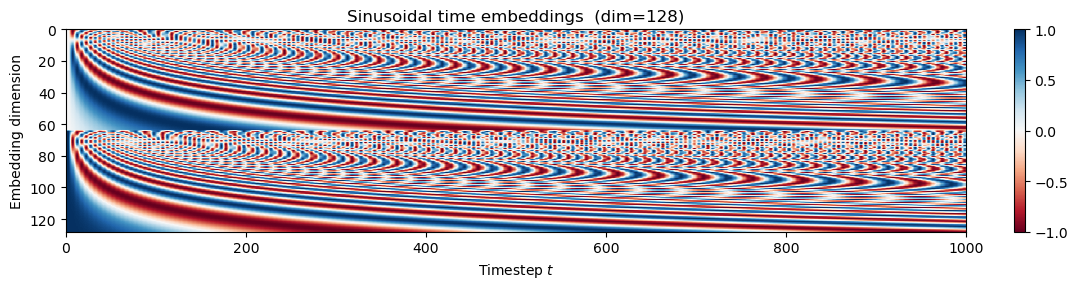

In [3]:
TIME_DIM = 128    # sinusoidal embedding dimension


class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding followed by a two-layer projection MLP.

    The sinusoidal encoding maps integer t → R^{TIME_DIM}.
    The MLP then projects to the model width with a non-linear transform.

    Sinusoidal formula:
        emb(t)_{2i}   = sin(t / 10000^{2i/(dim-1)})
        emb(t)_{2i+1} = cos(t / 10000^{2i/(dim-1)})
    """
    def __init__(self, dim=TIME_DIM, proj_dim=512):
        super().__init__()
        assert dim % 2 == 0
        self.dim      = dim
        self.proj_dim = proj_dim
        # Two-layer MLP to project sinusoidal → model width
        self.mlp = nn.Sequential(
            nn.Linear(dim, proj_dim),
            nn.SiLU(),
            nn.Linear(proj_dim, proj_dim),
        )

    def sinusoidal(self, t):
        """t : (B,) long → (B, dim) float32 sinusoidal encoding."""
        half  = self.dim // 2
        denom = self.dim - 2 if self.dim > 2 else 1
        freqs = torch.exp(
            -math.log(10000.0) *
            torch.arange(half, dtype=torch.float32, device=t.device) / denom
        )                                          # (half,)
        args  = t.float()[:, None] * freqs[None, :]  # (B, half)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)  # (B, dim)

    def forward(self, t):
        """t : (B,) long → (B, proj_dim) time features."""
        return self.mlp(self.sinusoidal(t))


# ── Quick shape test ──────────────────────────────────────────────────
_te = SinusoidalTimeEmbedding(TIME_DIM, proj_dim=512)
_t  = torch.tensor([0, 100, 500, 999])
print(f'Time embedding output shape: {_te(_t).shape}  (expected (4, 512))')

# Visualise the sinusoidal part
with torch.no_grad():
    emb_vis = _te.sinusoidal(torch.arange(0, T, 5))
fig, ax = plt.subplots(figsize=(11, 3))
ax.imshow(emb_vis.T.numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1,
          extent=[0, T, TIME_DIM, 0])
ax.set(xlabel='Timestep $t$', ylabel='Embedding dimension',
       title=f'Sinusoidal time embeddings  (dim={TIME_DIM})')
plt.colorbar(ax.images[0], ax=ax, fraction=0.015)
plt.tight_layout(); plt.show()

## 5. Noise-Prediction Network — `DiffusionMLP` as `nn.Module`

The architecture mirrors the NumPy version but with three improvements:

**1. SiLU instead of ReLU.**  $\mathrm{SiLU}(x) = x\,\sigma(x)$ is smooth
everywhere, avoids the 'dying ReLU' problem, and has become the standard
activation in diffusion models (Ho et al. use it in their UNet).

**2. `GroupNorm` after each dense layer.**  Normalisation stabilises
training, especially important because the model sees inputs at very
different noise scales ($t$ ranges from 0 to 999).  GroupNorm with
`num_groups=8` works well for width 512.

**3. Two-layer time MLP.**  Gives the network more capacity to modulate
its behaviour as a function of $t$.

Each **residual block**:
```
h1  = SiLU(GroupNorm(Linear(h_in)))
h1  = h1 + Linear(time_emb)          ← time injection
h2  = SiLU(GroupNorm(Linear(h1)))
out = h2 + skip(h_in)                ← residual
```

Because PyTorch's autograd handles backprop, the `backward` method
is just `loss.backward()` — no manual gradient computation needed.

In [4]:
class ResBlock(nn.Module):
    """
    One residual block of the diffusion MLP.

    Layout:
        h1  = SiLU(GN(W1 h_in + b1))
        h1 += W_t t_emb               (time injection, no bias)
        h2  = SiLU(GN(W2 h1 + b2))
        out = h2 + skip(h_in)
    """
    def __init__(self, in_dim, out_dim, time_dim):
        super().__init__()
        self.linear1 = nn.Linear(in_dim,  out_dim)
        self.linear2 = nn.Linear(out_dim, out_dim)
        self.norm1   = nn.GroupNorm(num_groups=min(8, out_dim), num_channels=out_dim)
        self.norm2   = nn.GroupNorm(num_groups=min(8, out_dim), num_channels=out_dim)
        self.act     = nn.SiLU()
        # Time projection: time_dim → out_dim  (no bias — standard)
        self.time_proj = nn.Linear(time_dim, out_dim, bias=False)
        # Skip connection
        self.skip = (
            nn.Linear(in_dim, out_dim, bias=False)
            if in_dim != out_dim
            else nn.Identity()
        )

    def forward(self, h, t_emb):
        """
        h     : (B, in_dim)
        t_emb : (B, time_dim)   projected time features
        Returns out : (B, out_dim)
        """
        # GroupNorm expects (B, C, *) — we treat width as channels
        h1  = self.act(self.norm1(self.linear1(h).unsqueeze(-1)).squeeze(-1))
        h1  = h1 + self.time_proj(t_emb)       # add time
        h2  = self.act(self.norm2(self.linear2(h1).unsqueeze(-1)).squeeze(-1))
        return h2 + self.skip(h)                # residual


class DiffusionMLP(nn.Module):
    """
    Time-conditioned noise-prediction MLP  ε_θ(x_t, t).

    Identical algorithm to the NumPy DiffusionMLP:
      • 3 residual blocks (784→512, 512→512, 512→512)
      • Sinusoidal time embedding + 2-layer MLP projection
      • Output layer Dense(512→784), no activation

    Improvements vs NumPy:
      • SiLU activation (smoother than ReLU)
      • GroupNorm for training stability
      • Two-layer time MLP (more expressive)
      • Autograd — no manual backward
    """
    def __init__(self, in_dim=784, width=512,
                 time_dim=TIME_DIM, n_blocks=3):
        super().__init__()
        self.in_dim   = in_dim
        self.width    = width
        self.n_blocks = n_blocks

        # Sinusoidal time embedding + projection MLP
        self.time_emb = SinusoidalTimeEmbedding(time_dim, proj_dim=width)

        # Residual blocks
        block_dims = [(in_dim, width)] + [(width, width)] * (n_blocks - 1)
        self.blocks = nn.ModuleList([
            ResBlock(fi, fo, time_dim=width)
            for fi, fo in block_dims
        ])

        # Output layer — predict raw noise (no activation)
        self.out = nn.Linear(width, in_dim)

        # Weight initialisation
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        # Small init on output layer (predict ~zero noise at start)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x_t, t):
        """
        x_t : (B, 784) noisy image in [-1, 1]
        t   : (B,)     integer timesteps in {0,...,T-1}
        Returns eps_hat : (B, 784)  predicted noise
        """
        t_emb = self.time_emb(t)           # (B, width)  projected time features
        h = x_t
        for block in self.blocks:
            h = block(h, t_emb)
        return self.out(h)                  # (B, 784)


# ── Instantiate and verify ────────────────────────────────────────────
model = DiffusionMLP(in_dim=784, width=512, time_dim=TIME_DIM, n_blocks=3).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DiffusionMLP parameters: {n_params:,}')

# Shape test
_x = torch.randn(4, 784, device=device)
_t = torch.tensor([0, 100, 500, 999], device=device)
with torch.no_grad():
    _out = model(_x, _t)
assert _out.shape == (4, 784), f'Bad shape: {_out.shape}'
print(f'Forward pass: ({4}, 784) → {tuple(_out.shape)}  ✓')

DiffusionMLP parameters: 3,640,080
Forward pass: (4, 784) → (4, 784)  ✓


## 6. MNIST with `torchvision` DataLoader

The PyTorch version uses `torchvision.datasets.MNIST` and `DataLoader`
for efficient batching and shuffling.  Pixels are rescaled from $[0,1]$
to $[-1,1]$ using the `Normalize(0.5, 0.5)` transform, which maps
$x \mapsto (x-0.5)/0.5 = 2x-1$, identical to the NumPy version.

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████| 9912422/9912422 [00:01<00:00, 9519251.40it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 253321.79it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████| 1648877/1648877 [00:01<00:00, 895617.18it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 1383480.67it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Train: 60,000 samples   Test: 10,000 samples
Batches per epoch: 235
Pixel range: [-1.0, 1.0]


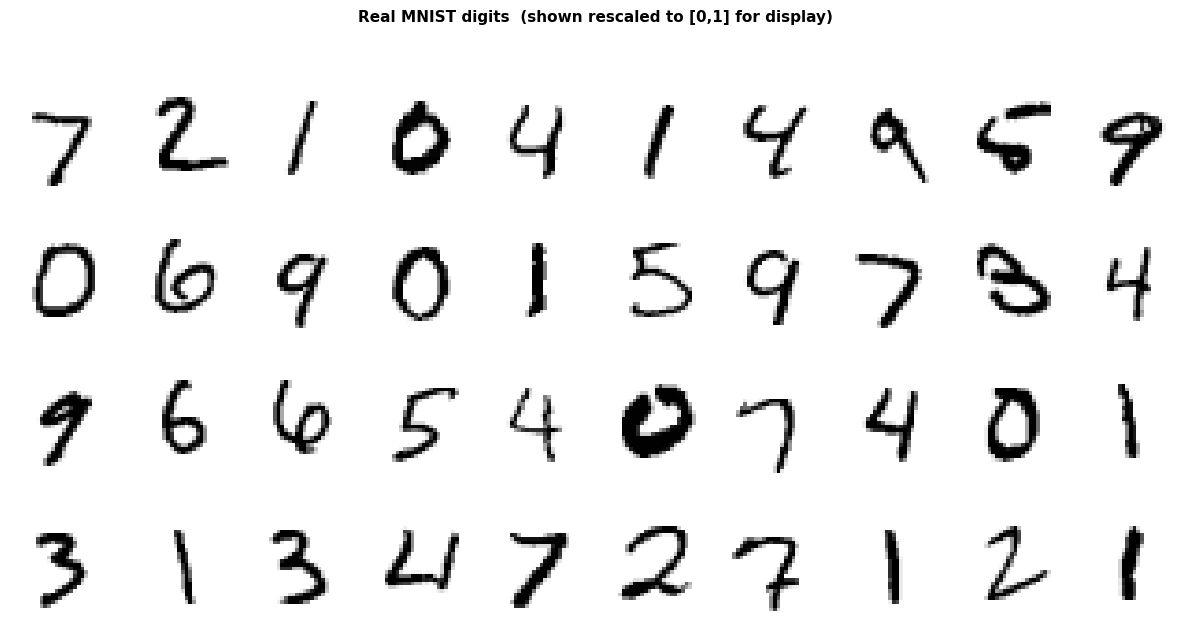

In [5]:
BATCH_SIZE = 256

transform = transforms.Compose([
    transforms.ToTensor(),             # [0,1]
    transforms.Normalize((0.5,), (0.5,)),   # → [-1,1]
    transforms.Lambda(lambda x: x.view(-1)),  # (1,28,28) → (784,)
])

train_dataset = datasets.MNIST('./data', train=True,
                                download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False,
                                download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset):,} samples   '
      f'Test: {len(test_dataset):,} samples')
print(f'Batches per epoch: {len(train_loader)}')

# Grab a fixed test batch for visualisations
X_test_batch, y_test_batch = next(iter(test_loader))
print(f'Pixel range: [{X_test_batch.min():.1f}, {X_test_batch.max():.1f}]')

show_grid((X_test_batch[:40] + 1) / 2, nrow=10,
          title='Real MNIST digits  (shown rescaled to [0,1] for display)')

## 7. Forward Diffusion — Visualising Noise Addition

Identical to the NumPy version: the closed-form one-shot
marginal $q(x_t|x_0)$ lets us jump directly to any noise level.

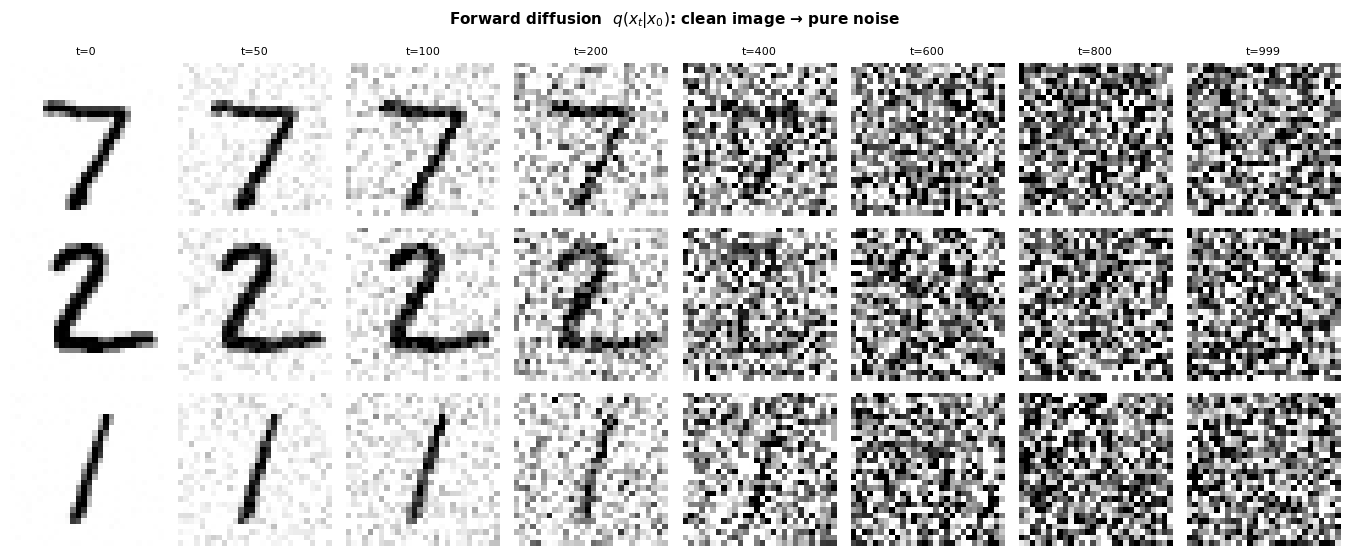

In [6]:
steps_shown = [0, 50, 100, 200, 400, 600, 800, 999]
n_demo      = 3

fig, axes = plt.subplots(n_demo, len(steps_shown),
                          figsize=(len(steps_shown)*1.7, n_demo*1.9),
                          squeeze=False)
x0_demo = X_test_batch[:n_demo]                   # (3, 784)
for row in range(n_demo):
    x0 = x0_demo[row:row+1]                        # (1, 784)
    for col, t in enumerate(steps_shown):
        t_idx = torch.tensor([t])
        with torch.no_grad():
            x_noisy, _ = q_sample(x0, t_idx)
        img = ((x_noisy[0] + 1) / 2).clamp(0, 1).reshape(28, 28).numpy()
        axes[row, col].imshow(img, cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={t}', fontsize=8)

fig.suptitle('Forward diffusion  $q(x_t|x_0)$: clean image → pure noise',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Training

The training loop is the same algorithm as NumPy but uses:
- `torch.optim.Adam` (replaces our hand-coded Adam)
- `loss.backward()` (replaces our hand-coded `backward` method)
- `DataLoader` for shuffled mini-batches
- `torch.no_grad()` contexts where gradients are not needed
- `torch.cuda.amp.autocast` for optional mixed-precision on NVIDIA GPUs

**Per-batch algorithm:**
1. Sample batch $x_0$ from DataLoader
2. Sample $t \sim \mathrm{Uniform}\{0,\ldots,T-1\}$ for each image
3. Sample $\varepsilon \sim \mathcal{N}(0,\mathbf{I})$
4. Compute $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\varepsilon$
5. Compute $\hat\varepsilon = \varepsilon_\theta(x_t, t)$
6. Loss $= \mathrm{MSE}(\varepsilon, \hat\varepsilon)$
7. `loss.backward()` + Adam step

In [ ]:
EPOCHS = 20
LR     = 2e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS)

history   = {'loss': []}
t0_train  = time.time()

print('Training DDPM — noise-prediction MSE')
print(f'  T={T}, epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LR}')
print(f'  {n_params:,} parameters,  device={device}')
print()

for ep in range(1, EPOCHS + 1):
    model.train()
    t_ep    = time.time()
    ep_loss = 0.0
    n_bat   = 0

    for x0, _ in train_loader:
        x0 = x0.to(device)                               # (B, 784)
        B  = x0.size(0)

        # Random timesteps, one per image
        t_idx = torch.randint(0, T, (B,), device=device) # (B,)

        # One-shot forward diffusion
        eps = torch.randn_like(x0)
        x_t, eps = q_sample(x0, t_idx, eps)              # (B, 784)

        # Predict noise
        eps_hat = model(x_t, t_idx)                       # (B, 784)

        # MSE loss and backprop
        loss = F.mse_loss(eps_hat, eps)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        ep_loss += loss.item()
        n_bat   += 1

    scheduler.step()
    ep_loss /= n_bat
    history['loss'].append(ep_loss)
    print(f'  Epoch {ep:3d}/{EPOCHS}  '
          f'loss = {ep_loss:.6f}  '
          f'lr = {scheduler.get_last_lr()[0]:.2e}  '
          f'({time.time()-t_ep:.1f}s)')

print(f'\nTotal training time: {time.time()-t0_train:.1f}s')

Training DDPM — noise-prediction MSE
  T=1000, epochs=20, batch=256, lr=0.0002
  3,640,080 parameters,  device=cpu



In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(range(1, EPOCHS+1), history['loss'], 'b-o', ms=5, lw=2)
ax.set(xlabel='Epoch',
       ylabel=r'MSE  $\|\varepsilon - \hat{\varepsilon}\|^2$',
       title='DDPM training loss on MNIST (PyTorch)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. DDPM Sampling — Full 1000-Step Reverse Chain

Same stochastic reverse process as NumPy.  The `@torch.no_grad()`
decorator disables gradient tracking during sampling, reducing
memory use and speeding up inference.

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}
\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\right)
+\sqrt{\tilde\beta_t}\,z, \quad z\sim\mathcal{N}(0,\mathbf{I}),\; z=0 \text{ at }t=0$$

In [ ]:
@torch.no_grad()
def ddpm_sample(mdl, n_samples=16, verbose=True):
    """
    DDPM stochastic reverse chain  x_T → x_0.

    x_{t-1} = (1/√α_t)(x_t − β_t/√(1-ᾱ_t) ε̂_t) + √β̃_t z
    """
    mdl.eval()
    x = torch.randn(n_samples, 784, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t,
                              dtype=torch.long, device=device)
        eps_hat = mdl(x, t_batch)

        # Reverse mean  μ_θ(x_t, t)
        alpha_t    = alphas_t[t].to(device)
        beta_t     = betas_t[t].to(device)
        sm_ab_t    = sqrt_1m_ab_t[t].to(device)
        mean = (x - beta_t / sm_ab_t * eps_hat) / torch.sqrt(alpha_t)

        if t > 0:
            z = torch.randn_like(x)
            x = mean + torch.sqrt(posterior_var_t[t].to(device)) * z
        else:
            x = mean

        if verbose and t % 200 == 0:
            print(f'  t={t:4d}   range [{x.min():.2f}, {x.max():.2f}]')

    return x


print('DDPM sampling (1000 steps)...')
t0 = time.time()
x_ddpm = ddpm_sample(model, n_samples=16, verbose=True)
print(f'Done in {time.time()-t0:.1f}s')

show_grid((x_ddpm + 1) / 2, nrow=8,
          title='DDPM generated samples  (1000 stochastic reverse steps)')

## 10. DDIM Accelerated Sampling — 50 Deterministic Steps

Deterministic ($\eta=0$) DDIM with 50 steps — identical algorithm to
the NumPy version, just operating on tensors:

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat{x}_0
+\sqrt{1-\bar\alpha_{t-1}}\,\varepsilon_\theta(x_t,t)$$

$$\hat{x}_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,
\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.$$

In [ ]:
@torch.no_grad()
def ddim_sample(mdl, n_samples=16, n_steps=50, verbose=True):
    """
    Deterministic DDIM reverse chain  (η=0).

    Selects n_steps evenly-spaced timesteps, runs them descending.
    """
    mdl.eval()
    # Evenly spaced timesteps, descending
    tau = torch.linspace(0, T-1, n_steps, dtype=torch.long)  # ascending
    tau = tau.flip(0)                                          # descending

    x = torch.randn(n_samples, 784, device=device)

    for i, t in enumerate(tau):
        t_val   = t.item()
        t_batch = torch.full((n_samples,), t_val,
                              dtype=torch.long, device=device)
        eps_hat = mdl(x, t_batch)

        ab_t    = alpha_bar_t[t_val].to(device)
        ab_prev = (
            alpha_bar_t[tau[i+1].item()].to(device)
            if i + 1 < n_steps else torch.ones(1, device=device)
        )

        # Predict x0
        x0_pred = (x - torch.sqrt(1 - ab_t) * eps_hat) / torch.sqrt(ab_t)
        x0_pred = x0_pred.clamp(-2.0, 2.0)

        # DDIM deterministic step
        x = torch.sqrt(ab_prev) * x0_pred + torch.sqrt(1 - ab_prev) * eps_hat

        if verbose and i % 10 == 0:
            print(f'  step {i:3d}/{n_steps}  t={t_val:4d}'
                  f'  range [{x.min():.2f}, {x.max():.2f}]')

    return x


print('DDIM sampling (50 steps)...')
t0 = time.time()
x_ddim = ddim_sample(model, n_samples=80, n_steps=50, verbose=True)
print(f'Done in {time.time()-t0:.1f}s')

show_grid((x_ddim + 1) / 2, nrow=10,
          title='DDIM generated samples  (50 deterministic steps, PyTorch)')

## 11. Analysis

Same three diagnostics as the NumPy notebook:
1. Single-step $\hat{x}_0$ reconstruction at various noise levels
2. DDIM chain evolution — noise condensing into digits
3. Noise prediction scatter — $\varepsilon$ vs $\hat\varepsilon$

In [ ]:
# ── 1. Single-step x0 reconstruction ─────────────────────────────────
model.eval()
t_vals  = [50, 200, 400, 700, 900]
n_eval  = 8
x0_eval = X_test_batch[:n_eval].to(device)

fig, axes = plt.subplots(len(t_vals)+1, n_eval,
                          figsize=(n_eval*1.6, (len(t_vals)+1)*1.8),
                          squeeze=False)
# Row 0: originals
for j in range(n_eval):
    axes[0,j].imshow(((x0_eval[j]+1)/2).clamp(0,1).reshape(28,28).cpu().numpy(),
                     cmap='gray_r', vmin=0, vmax=1)
    axes[0,j].axis('off')
axes[0,0].set_ylabel('Clean', fontsize=8, rotation=0, labelpad=30, va='center')

with torch.no_grad():
    for row, t in enumerate(t_vals, 1):
        t_arr     = torch.full((n_eval,), t, dtype=torch.long, device=device)
        x_noisy,_ = q_sample(x0_eval, t_arr)
        eps_hat   = model(x_noisy, t_arr)
        # x0_hat = (x_t - √(1-ᾱ_t) ε̂) / √ᾱ_t
        x0_hat    = ((x_noisy - sqrt_1m_ab_t[t].to(device) * eps_hat)
                      / sqrt_ab_t[t].to(device))
        for j in range(n_eval):
            axes[row,j].imshow(
                ((x0_hat[j]+1)/2).clamp(0,1).reshape(28,28).cpu().numpy(),
                cmap='gray_r', vmin=0, vmax=1)
            axes[row,j].axis('off')
        axes[row,0].set_ylabel(f't={t}', fontsize=8, rotation=0,
                               labelpad=30, va='center')

fig.suptitle(r'Single-step $\hat{x}_0$ reconstruction from $x_t$'
             r'  (row = noise level)',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 2. DDIM chain evolution ────────────────────────────────────────────
n_steps  = 50
tau_list = torch.linspace(0, T-1, n_steps, dtype=torch.long).flip(0)
snap_at  = {0, 5, 10, 20, 30, 40, 49}
n_chains = 4

x_ev  = torch.randn(n_chains, 784, device=device)
snaps = {}

model.eval()
with torch.no_grad():
    for i, t in enumerate(tau_list):
        t_val = t.item()
        if i in snap_at:
            snaps[i] = ((x_ev+1)/2).clamp(0,1).reshape(n_chains,28,28).cpu().numpy().copy()
        t_b     = torch.full((n_chains,), t_val, dtype=torch.long, device=device)
        eps_hat = model(x_ev, t_b)
        ab_t    = alpha_bar_t[t_val].to(device)
        ab_prev = (alpha_bar_t[tau_list[i+1].item()].to(device)
                   if i+1 < n_steps else torch.ones(1, device=device))
        x0_pred = (x_ev - torch.sqrt(1-ab_t)*eps_hat) / torch.sqrt(ab_t)
        x0_pred = x0_pred.clamp(-2.0, 2.0)
        x_ev    = torch.sqrt(ab_prev)*x0_pred + torch.sqrt(1-ab_prev)*eps_hat
    snaps[n_steps-1] = ((x_ev+1)/2).clamp(0,1).reshape(n_chains,28,28).cpu().numpy()

ordered = sorted(snaps.items())
fig, axes = plt.subplots(n_chains, len(ordered),
                          figsize=(len(ordered)*1.8, n_chains*1.9),
                          squeeze=False)
for row in range(n_chains):
    for col, (step_i, imgs) in enumerate(ordered):
        axes[row,col].imshow(imgs[row], cmap='gray_r', vmin=0, vmax=1)
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(f'step {step_i}', fontsize=8)
fig.suptitle('DDIM chain evolution: noise → digit  (4 chains, PyTorch)',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── 3. Noise prediction scatter ε vs ε̂ ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), squeeze=False)
t_scatter = [100, 500, 900]
n_sc      = 512
x0_sc     = X_test_batch[:n_sc].to(device)

model.eval()
with torch.no_grad():
    for ax, t in zip(axes[0], t_scatter):
        t_arr    = torch.full((n_sc,), t, dtype=torch.long, device=device)
        x_t, eps = q_sample(x0_sc, t_arr)
        eps_hat  = model(x_t, t_arr)
        mse      = F.mse_loss(eps_hat, eps).item()

        eps_np     = eps.cpu().numpy().ravel()
        eps_hat_np = eps_hat.cpu().numpy().ravel()
        idx        = np.random.choice(len(eps_np), 3000, replace=False)
        ax.scatter(eps_np[idx], eps_hat_np[idx],
                   s=2, alpha=0.25, color='steelblue')
        lo = min(eps_np.min(), eps_hat_np.min())
        hi = max(eps_np.max(), eps_hat_np.max())
        ax.plot([lo,hi],[lo,hi],'r--',lw=1.5,label='Ideal')
        ax.set(xlabel=r'True noise $\varepsilon$',
               ylabel=r'Predicted $\hat{\varepsilon}$',
               title=f't = {t}\nMSE = {mse:.4f}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Noise prediction quality  (PyTorch)',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

### NumPy vs PyTorch — line-by-line comparison

| Step | NumPy version | PyTorch version |
|:-----|:-------------|:----------------|
| Forward pass | `h = h @ W + b`, ReLU, manual time inject | `block(h, t_emb)` via `nn.Linear` + SiLU + GN |
| Time embedding | `sinusoidal_embedding(t)` → NumPy | `SinusoidalTimeEmbedding` → 2-layer MLP |
| Backward | Manual `backward()` method (100 lines) | `loss.backward()` (1 line) |
| Optimiser | Hand-coded `Adam` class | `torch.optim.Adam` |
| Schedule | NumPy arrays indexed by `t` | Tensors moved to `device` |
| Data loading | Manual loop over NumPy arrays | `DataLoader` with shuffle |
| `q_sample` | NumPy ops | Same formula, tensor ops |
| DDPM sampling | NumPy loop, 1000 steps | `@torch.no_grad()` loop, 1000 steps |
| DDIM sampling | NumPy loop, 50 steps | `@torch.no_grad()` loop, 50 steps |
| GPU support | ✗ | ✓ via `.to(device)` |

### All three generative models — unified comparison

| | RBM | VAE | DDPM (NumPy) | DDPM (PyTorch) |
|:-|:----|:----|:------------|:---------------|
| **Framework** | NumPy | NumPy | NumPy | PyTorch + GPU |
| **Latent** | Binary $h$ | Gaussian $z$ | None | None |
| **Training** | CD-$k$ | ELBO | Noise MSE | Noise MSE |
| **Sampling** | Gibbs (MCMC) | One decode | 1000 steps | 1000 steps |
| **Fast sampling** | — | — | DDIM 50 steps | DDIM 50 steps |
| **Autograd** | ✗ | ✗ | ✗ | ✓ |
| **GPU** | ✗ | ✗ | ✗ | ✓ |